In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look clean and professional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")

print("All libraries loaded!")

All libraries loaded!


In [2]:
# Load the dataset
df = pd.read_csv('data/archive (1)/Sample - Superstore.csv', encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
# Convert dates to proper format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')  # Jan, Feb...
df['Quarter'] = df['Order Date'].dt.quarter

print(" Dates fixed!")
print(df[['Order Date', 'Year', 'Month', 'Month Name', 'Quarter']].head())

 Dates fixed!
  Order Date  Year  Month Month Name  Quarter
0 2016-11-08  2016     11        Nov        4
1 2016-11-08  2016     11        Nov        4
2 2016-06-12  2016      6        Jun        2
3 2015-10-11  2015     10        Oct        4
4 2015-10-11  2015     10        Oct        4


In [11]:
# Overall KPIs — this is what goes on your resume as "extracted KPIs"
total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
total_orders   = df['Order ID'].nunique()
profit_margin  = (total_profit / total_sales) * 100
avg_order_val  = total_sales / total_orders

print("=" * 40)
print("        BUSINESS KPI SUMMARY")
print("=" * 40)
print(f" Total Sales      : ${total_sales:,.2f}")
print(f" Total Profit     : ${total_profit:,.2f}")
print(f" Total Orders     : {total_orders:,}")
print(f" Profit Margin    : {profit_margin:.2f}%")
print(f" Avg Order Value  : ${avg_order_val:,.2f}")
print("=" * 40)

        BUSINESS KPI SUMMARY
 Total Sales      : $2,297,200.86
 Total Profit     : $286,397.02
 Total Orders     : 5,009
 Profit Margin    : 12.47%
 Avg Order Value  : $458.61


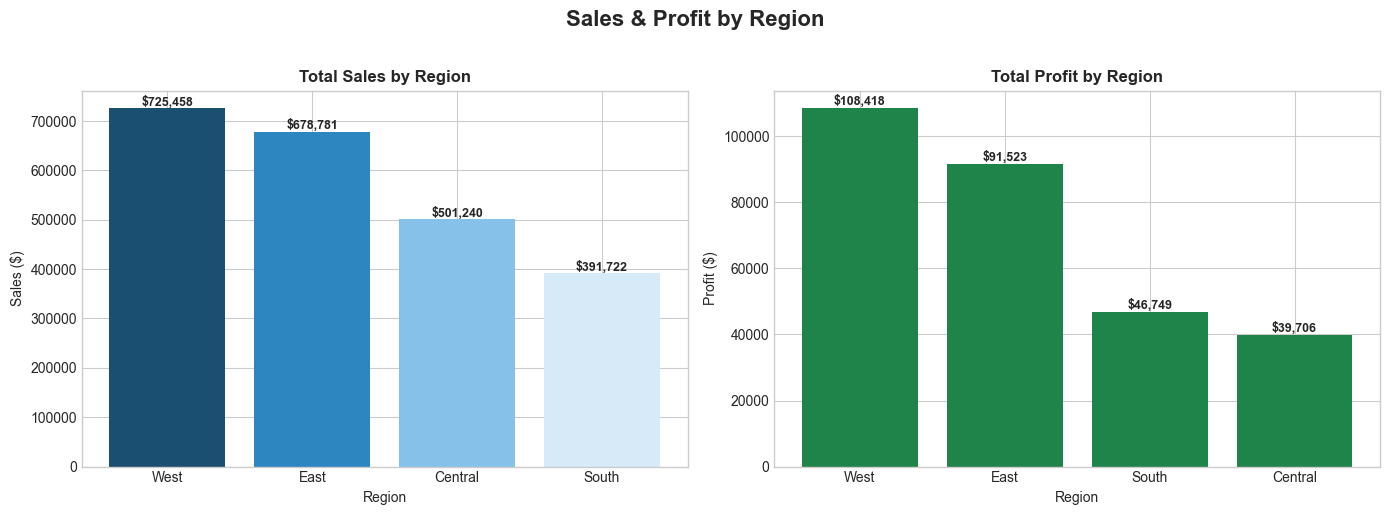

Chart 1 saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales & Profit by Region', fontsize=16, fontweight='bold', y=1.02)

# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
bars = axes[0].bar(region_sales.index, region_sales.values, 
                    color=['#1B4F72','#2E86C1','#85C1E9','#D6EAF8'])
axes[0].set_title('Total Sales by Region', fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Sales ($)')
for bar, val in zip(bars, region_sales.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors = ['#1E8449' if v > 0 else '#C0392B' for v in region_profit.values]
bars2 = axes[1].bar(region_profit.index, region_profit.values, color=colors)
axes[1].set_title('Total Profit by Region', fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Profit ($)')
for bar, val in zip(bars2, region_profit.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

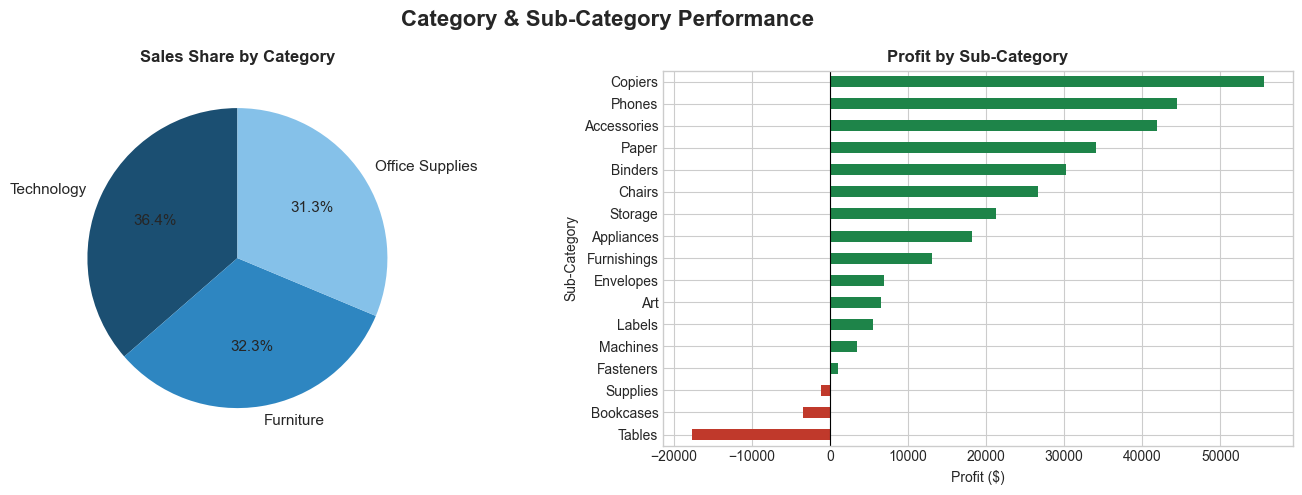

 Chart 2 saved!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category & Sub-Category Performance', fontsize=16, fontweight='bold')

# Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
            colors=['#1B4F72','#2E86C1','#85C1E9'],
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Sales Share by Category', fontweight='bold')

# Top 10 Sub-Categories by Profit
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#C0392B' if v < 0 else '#1E8449' for v in subcat_profit.values]
subcat_profit.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Profit by Sub-Category', fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('chart2_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 2 saved!")

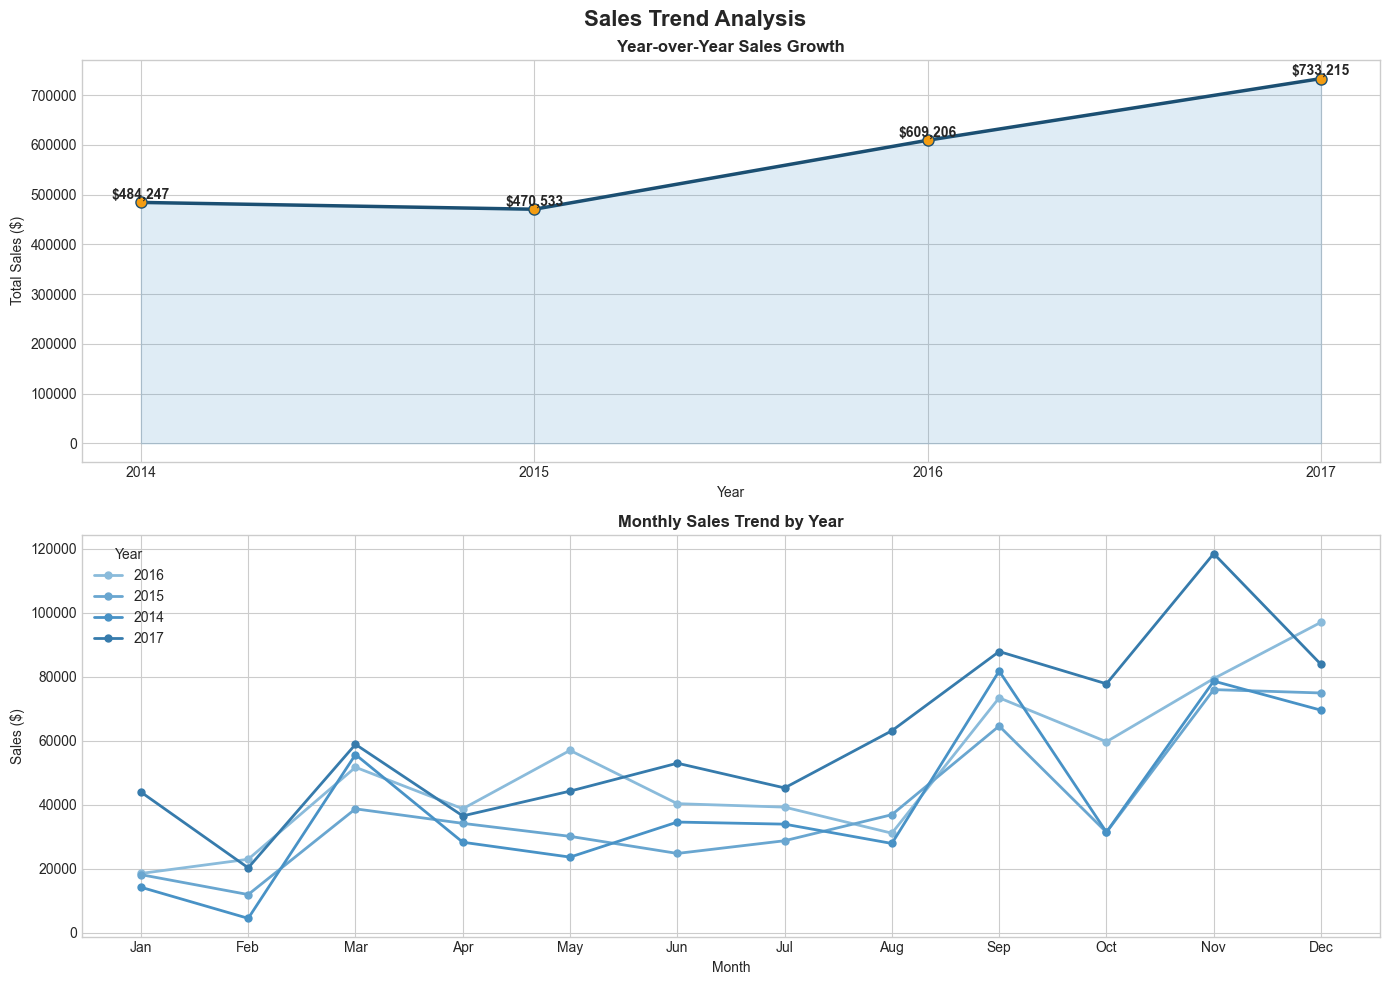

 Chart 3 saved!


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Sales Trend Analysis', fontsize=16, fontweight='bold')

# Yearly Sales Trend
yearly = df.groupby('Year')['Sales'].sum()
axes[0].plot(yearly.index, yearly.values, marker='o', linewidth=2.5,
             color='#1B4F72', markersize=8, markerfacecolor='#F39C12')
axes[0].fill_between(yearly.index, yearly.values, alpha=0.15, color='#2E86C1')
for x, y in zip(yearly.index, yearly.values):
    axes[0].text(x, y + 8000, f'${y:,.0f}', ha='center', 
                 fontweight='bold', fontsize=10)
axes[0].set_title('Year-over-Year Sales Growth', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xticks(yearly.index)

# Monthly Sales by Year
for year in df['Year'].unique():
    yearly_data = df[df['Year'] == year].groupby('Month')['Sales'].sum()
    axes[1].plot(yearly_data.index, yearly_data.values, 
                 marker='o', linewidth=2, label=str(year), markersize=5)
axes[1].set_title('Monthly Sales Trend by Year', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales ($)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend(title='Year')

plt.tight_layout()
plt.savefig('chart3_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 3 saved!")

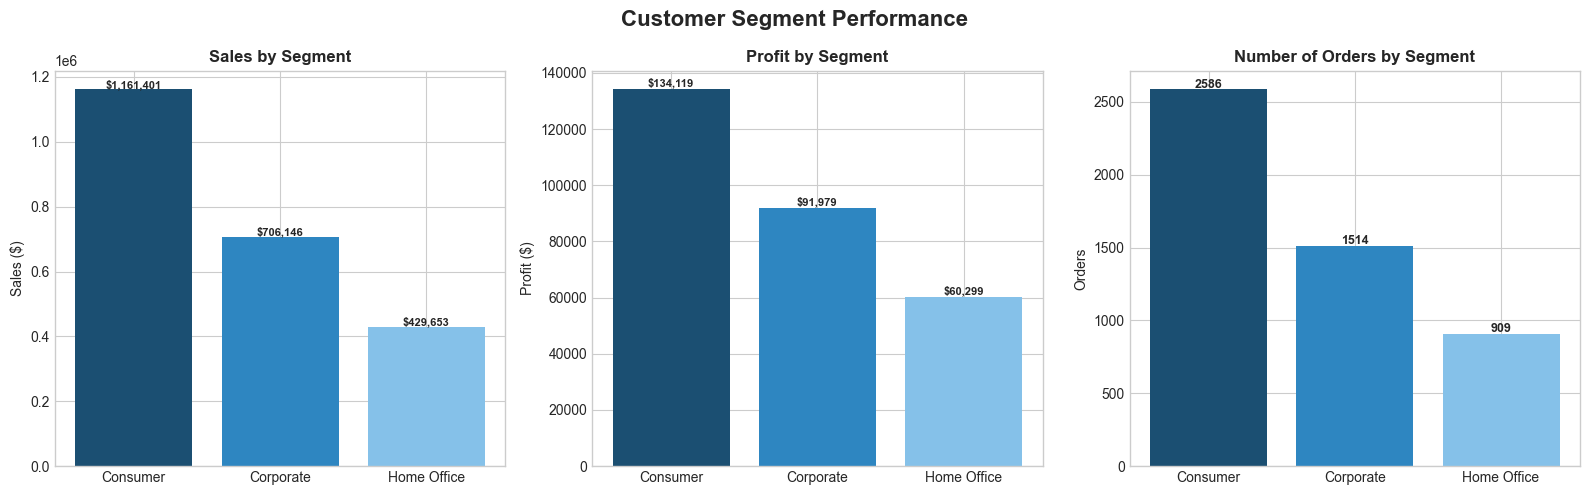

 Chart 4 saved!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Segment Performance', fontsize=16, fontweight='bold')

segments = df.groupby('Segment').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index()

colors = ['#1B4F72', '#2E86C1', '#85C1E9']

# Sales by Segment
axes[0].bar(segments['Segment'], segments['Sales'], color=colors)
axes[0].set_title('Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
for i, (seg, val) in enumerate(zip(segments['Segment'], segments['Sales'])):
    axes[0].text(i, val + 5000, f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')

# Profit by Segment
axes[1].bar(segments['Segment'], segments['Profit'], color=colors)
axes[1].set_title('Profit by Segment', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
for i, (seg, val) in enumerate(zip(segments['Segment'], segments['Profit'])):
    axes[1].text(i, val + 1000, f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')

# Orders by Segment
axes[2].bar(segments['Segment'], segments['Orders'], color=colors)
axes[2].set_title('Number of Orders by Segment', fontweight='bold')
axes[2].set_ylabel('Orders')
for i, (seg, val) in enumerate(zip(segments['Segment'], segments['Orders'])):
    axes[2].text(i, val + 10, str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 4 saved!")

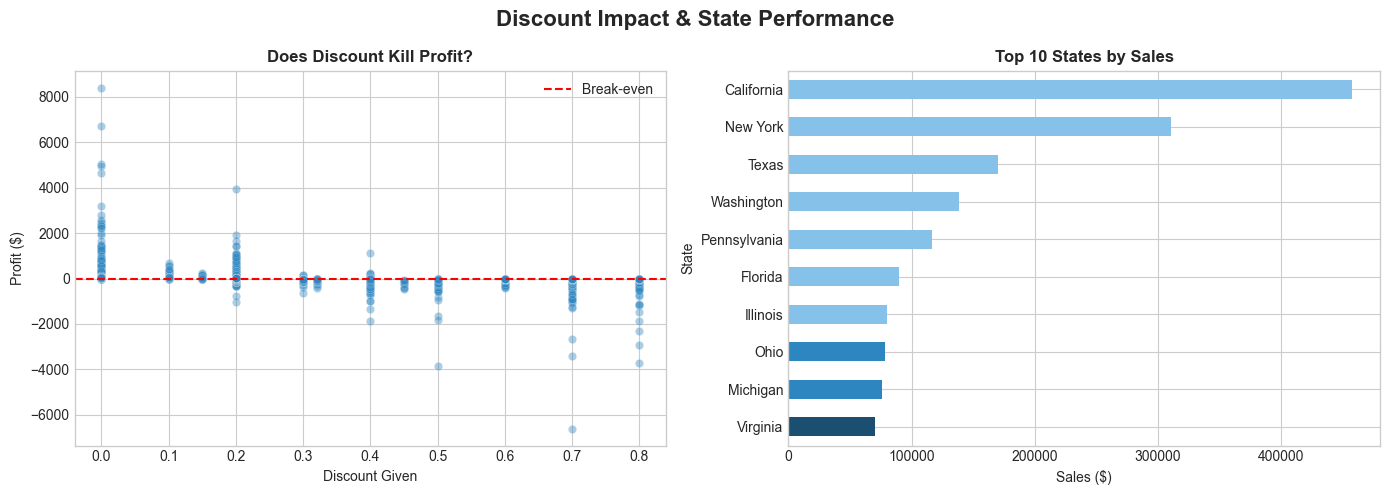

Chart 5 saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discount Impact & State Performance', fontsize=16, fontweight='bold')

# Discount vs Profit scatter
axes[0].scatter(df['Discount'], df['Profit'], alpha=0.4, 
                color='#2E86C1', edgecolors='white', linewidth=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[0].set_title('Does Discount Kill Profit?', fontweight='bold')
axes[0].set_xlabel('Discount Given')
axes[0].set_ylabel('Profit ($)')
axes[0].legend()

# Top 10 States by Sales
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
colors_states = ['#1B4F72' if i == 0 else '#2E86C1' if i < 3 else '#85C1E9' 
                 for i in range(len(top_states))]
top_states.plot(kind='barh', ax=axes[1], color=colors_states[::-1])
axes[1].set_title('Top 10 States by Sales', fontweight='bold')
axes[1].set_xlabel('Sales ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('chart5_discount_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

In [19]:
# Year over Year Growth calculation
yoy = df.groupby('Year')['Sales'].sum()
growth_2017 = ((yoy[2017] - yoy[2016]) / yoy[2016]) * 100
growth_2016 = ((yoy[2016] - yoy[2015]) / yoy[2015]) * 100

# Best and worst performers
best_region   = df.groupby('Region')['Profit'].sum().idxmax()
worst_subcat  = df.groupby('Sub-Category')['Profit'].sum().idxmin()
best_subcat   = df.groupby('Sub-Category')['Profit'].sum().idxmax()
best_segment  = df.groupby('Segment')['Sales'].sum().idxmax()
peak_month    = df.groupby('Month Name')['Sales'].sum().idxmax()

print("=" * 50)
print("     EXECUTIVE SUMMARY — KEY INSIGHTS")
print("=" * 50)
print(f" YoY Growth 2015→2016  : {growth_2016:.1f}%")
print(f" YoY Growth 2016→2017  : {growth_2017:.1f}%")
print(f" Most Profitable Region : {best_region}")
print(f" Best Sub-Category      : {best_subcat}")
print(f"  Loss-Making Sub-Cat   : {worst_subcat}")
print(f" Top Customer Segment   : {best_segment}")
print(f" Peak Sales Month       : {peak_month}")
print(f" Insight: High discounts consistently lead to negative profit")
print(f" Insight: Tables sub-category needs urgent review")
print("=" * 50)
print("\n PROJECT COMPLETE! All 5 charts saved.")

     EXECUTIVE SUMMARY — KEY INSIGHTS
 YoY Growth 2015→2016  : 29.5%
 YoY Growth 2016→2017  : 20.4%
 Most Profitable Region : West
 Best Sub-Category      : Copiers
  Loss-Making Sub-Cat   : Tables
 Top Customer Segment   : Consumer
 Peak Sales Month       : Nov
 Insight: High discounts consistently lead to negative profit
 Insight: Tables sub-category needs urgent review

 PROJECT COMPLETE! All 5 charts saved.
